# Análisis de datos
## Clase 2
### Actividad individual N°2 - Dataset "Maní - siembra, cosecha, producción, rendimiento"

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

[Pagina de origen del dataset : https://datos.gob.ar/dataset/agroindustria](https://datos.gob.ar/dataset/agroindustria-mani---siembra-cosecha-produccion-rendimiento)

In [107]:
#Se debe abrir el archivo .csv con una codificacion ISO-8859-1 (Latin-1) no la UTF-8.

df = pd.read_csv("mani-serie-1927-2024.csv" , encoding='latin1')

In [108]:
#Determinamos el tamaño del dataset

print(f"El dataset contiene: {df.shape[0]} filas y  {df.shape[1]} columnas")

El dataset contiene: 5257 filas y  11 columnas


In [109]:
#Determinamos el nombre de las columnas y que tipo de variable contienen

print("****Las variables/columnas del dataset****")
print("\n")
for columna in df.columns:
    print(f"{columna}-------->({df[columna].dtype.name})")
print("\n")

****Las variables/columnas del dataset****


cultivo-------->(object)
anio-------->(int64)
campania-------->(object)
provincia-------->(object)
provincia_id-------->(int64)
departamento-------->(object)
departamento_id-------->(float64)
superficie_sembrada_ha-------->(float64)
superficie_cosechada_ha-------->(float64)
produccion_tm-------->(float64)
rendimiento_kgxha-------->(float64)




### Analisis del tipo de variables encontradas


| Variable | Tipo de variable | Descripción |
| :--- | :---: | :--- |
| `cultivo` | Categorica nominal | Nombre del cultivo. |
| `año` | Categorica ordinal | Año que correspondan los datos. |
| `campania` | Categorica ordinal | Campaña en la que se desarrollo el cultivo. |
| `provincia` | Categorica nominal | Nombre de la provincia. |
| `provincia_id` | Categorica nominal | Código de la provincia. |
| `departamento` | Categorica nominal | Nombre del departamento. |
| `departamento_id` | Categorica nominal | Código del departamento. |
| `superficie_sembrada_ha` | Numerica continua | Superficie sembrada en hectáreas. |
| `superficie_cosechada_ha` | Numerica continua | Superficie cosechada en hectáreas. |
| `produccion_tm` | Numerica continua | Produccion en toneladas. |
| `rendimiento_kgxha` | Numerica continua | Rendimiento en kilos por hectárea. |


In [110]:
#Renombramos la variable de columna, corrigiendola.

df = df.rename(columns={'anio': 'año'})
df['año'] = df['año'].astype(int).astype(str)

In [111]:
#Se verifica si existen columnas con valores nulos y/o faltantes y que cantidad.
df.isna().mean().round(4) * 100


cultivo                    0.00
año                        0.00
campania                   0.00
provincia                  0.00
provincia_id               0.00
departamento               0.13
departamento_id            0.61
superficie_sembrada_ha     0.00
superficie_cosechada_ha    2.83
produccion_tm              2.83
rendimiento_kgxha          2.85
dtype: float64

In [112]:
#Para procesar correctamente las variables categoricas como "provincia id" y "departamento id" 
#se convierten a variables tipo string ya que no tiene sentido procesarlas como un numero.


In [113]:
#Agregar 'sin datos' a los valores vacios o nulos de la columna departamento

df['departamento'].fillna('Sin datos', inplace=True)

In [114]:
#Agregar '0.0' a los valores vacios o nulos de la columna departamento_id y se cambia el tipo de variable para tratarla como string simplemente para 
#evitar confusiones y no permitir calculos numericos.

df['departamento_id'].fillna(0.0 , inplace=True)
df['departamento_id'] = df['departamento_id'].astype(int).astype(str)

In [115]:
#Se cambia el tipo de variable para tratarla como string simplemente para evitar confusiones y no permitir calculos numericos.

df['provincia_id'] = df['provincia_id'].astype(int).astype(str)

## Exploración de VARIABLES NUMÉRICAS
### Medidas de tendencia central: media, mediana y moda

* MEDIA

In [116]:
print(f'La media de la superficie sembrada: {df['superficie_sembrada_ha'].mean():.2f} (ha)')
print(f'La media de la superficie cosechada: {df['superficie_cosechada_ha'].mean():.2f} (ha)')
print(f'La media de la produccion: {df['produccion_tm'].mean():.2f} (tm)')
print(f'La media del rendimiento: {df['rendimiento_kgxha'].mean():.2f} (kg.ha)')

La media de la superficie sembrada: 4356.96 (ha)
La media de la superficie cosechada: 4302.73 (ha)
La media de la produccion: 7488.13 (tm)
La media del rendimiento: 1180.48 (kg.ha)


* MEDIANA

In [117]:
print(f'La moda de la superficie sembrada: {df['superficie_sembrada_ha'].median():.2f} (ha)')
print(f'La moda de la superficie cosechada: {df['superficie_cosechada_ha'].median():.2f} (ha)')
print(f'La moda de la produccion: {df['produccion_tm'].median():.2f} (tm)')
print(f'La moda del rendimiento: {df['rendimiento_kgxha'].median():.2f} (kg.ha)')

La moda de la superficie sembrada: 50.00 (ha)
La moda de la superficie cosechada: 48.00 (ha)
La moda de la produccion: 40.00 (tm)
La moda del rendimiento: 1000.00 (kg.ha)


* MODA

In [118]:
print(f'La moda de la superficie sembrada: {df['superficie_sembrada_ha'].mode()[0]:.2f} (ha)')
print(f'La moda de la superficie cosechada: {df['superficie_cosechada_ha'].mode()[0]:.2f} (ha)')
print(f'La moda de la produccion: {df['produccion_tm'].mode()[0]:.2f} (tm)')
print(f'La moda del rendimiento: {df['rendimiento_kgxha'].mode()[0]:.2f} (kg.ha)')

La moda de la superficie sembrada: 10.00 (ha)
La moda de la superficie cosechada: 5.00 (ha)
La moda de la produccion: 2.00 (tm)
La moda del rendimiento: 1000.00 (kg.ha)


### Medidas de forma: skewness y curtosis

* SKEWNESS (ASIMETRIA)

In [120]:
print(f'La moda de la superficie sembrada: {df['superficie_sembrada_ha'].skew():.2f} (ha)')
print(f'La moda de la superficie cosechada: {df['superficie_cosechada_ha'].skew():.2f} (ha)')
print(f'La moda de la produccion: {df['produccion_tm'].skew():.2f} (tm)')
print(f'La moda del rendimiento: {df['rendimiento_kgxha'].skew():.2f} (kg.ha)')

La moda de la superficie sembrada: 5.75 (ha)
La moda de la superficie cosechada: 5.69 (ha)
La moda de la produccion: 6.80 (tm)
La moda del rendimiento: 2.40 (kg.ha)


* CURTOSIS

In [121]:
print(f'La moda de la superficie sembrada: {df['superficie_sembrada_ha'].kurt():.2f} (ha)')
print(f'La moda de la superficie cosechada: {df['superficie_cosechada_ha'].kurt():.2f} (ha)')
print(f'La moda de la produccion: {df['produccion_tm'].kurt():.2f} (tm)')
print(f'La moda del rendimiento: {df['rendimiento_kgxha'].kurt():.2f} (kg.ha)')

La moda de la superficie sembrada: 39.75 (ha)
La moda de la superficie cosechada: 38.76 (ha)
La moda de la produccion: 57.91 (tm)
La moda del rendimiento: 11.70 (kg.ha)


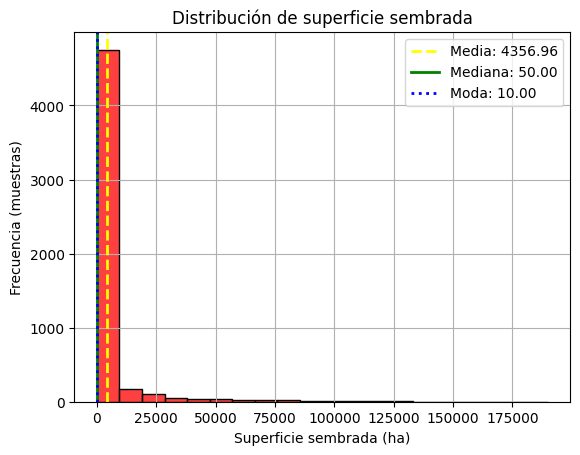

In [152]:
#Definimos las metricas en variables
media = df['superficie_sembrada_ha'].mean() 
mediana = df['superficie_sembrada_ha'].median() 
moda = df['superficie_sembrada_ha'].mode()[0]

# Generamos un histograma
sns.histplot(data=df, x='superficie_sembrada_ha', bins=20, color='red')

#Se agregan las medidas de tendencia
plt.axvline(x=media, color='yellow', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(x=mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(x=moda, color='blue', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}')

# Asignamos los nombres a los ejes y el titulo
plt.title('Distribución de superficie sembrada')
plt.xlabel('Superficie sembrada (ha)')
plt.ylabel('Frecuencia (muestras)')
plt.grid(True)
plt.legend() 
plt.show()

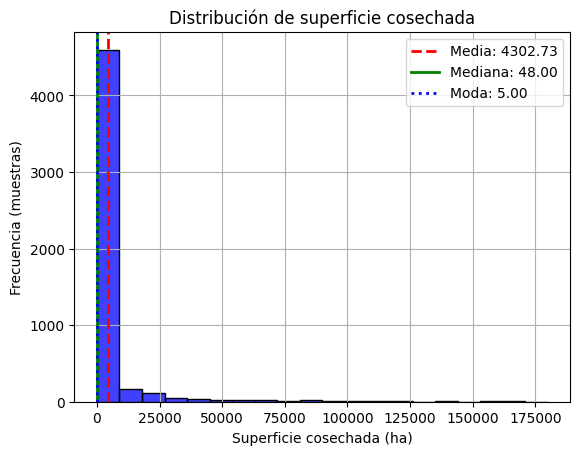

In [154]:
#Definimos las metricas en variables
media = df['superficie_cosechada_ha'].mean() 
mediana = df['superficie_cosechada_ha'].median() 
moda = df['superficie_cosechada_ha'].mode()[0]

# Generamos un histograma
sns.histplot(data=df, x='superficie_cosechada_ha', bins=20, color='blue')

#Se agregan las medidas de tendencia
plt.axvline(x=media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(x=mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(x=moda, color='blue', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}')

# Asignamos los nombres a los ejes y el titulo
plt.title('Distribución de superficie cosechada')
plt.xlabel('Superficie cosechada (ha)')
plt.ylabel('Frecuencia (muestras)')
plt.grid(True)
plt.legend() 
plt.show()

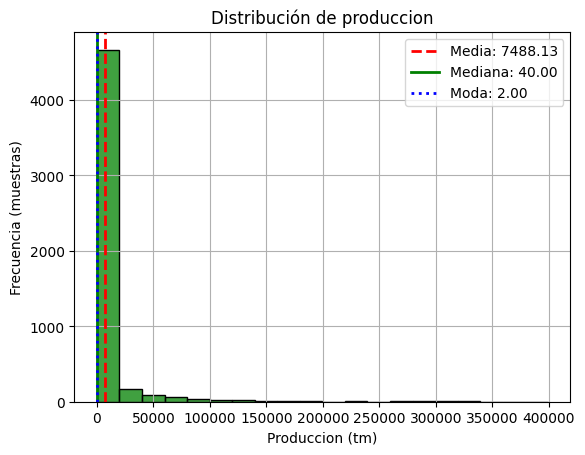

In [156]:
#Definimos las metricas en variables
media = df['produccion_tm'].mean() 
mediana = df['produccion_tm'].median() 
moda = df['produccion_tm'].mode()[0]

# Generamos un histograma
sns.histplot(data=df, x='produccion_tm', bins=20, color='green')

#Se agregan las medidas de tendencia
plt.axvline(x=media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(x=mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(x=moda, color='blue', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}')

# Asignamos los nombres a los ejes y el titulo
plt.title('Distribución de produccion')
plt.xlabel('Produccion (tm)')
plt.ylabel('Frecuencia (muestras)')
plt.grid(True)
plt.legend() 
plt.show()

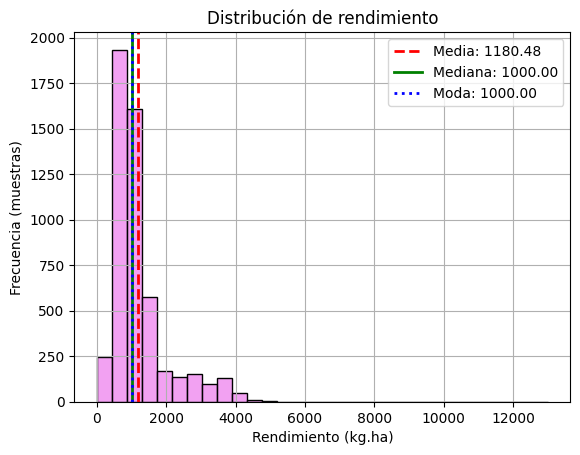

In [190]:
#Definimos las metricas en variables
media = df['rendimiento_kgxha'].mean() 
mediana = df['rendimiento_kgxha'].median() 
moda = df['rendimiento_kgxha'].mode()[0]

#Generamos un histograma
sns.histplot(data=df, x='rendimiento_kgxha', bins=30, color='violet')

#Se agregan las medidas de tendencia
plt.axvline(x=media, color='red', linestyle='--', linewidth=2, label=f'Media: {media:.2f}')
plt.axvline(x=mediana, color='green', linestyle='-', linewidth=2, label=f'Mediana: {mediana:.2f}')
plt.axvline(x=moda, color='blue', linestyle=':', linewidth=2, label=f'Moda: {moda:.2f}')

# Asignamos los nombres a los ejes y el titulo
plt.title('Distribución de rendimiento')
plt.xlabel('Rendimiento (kg.ha)')
plt.ylabel('Frecuencia (muestras)')
plt.grid(True)
plt.legend() 
plt.show()


### Medidas de dispersión: Cuartiles, rango intercuartil, varianza y desviación estándar 

* CUARTILES Y RANGO INTERCUARTIL

In [162]:
Q1, Q2, Q3 = df['superficie_sembrada_ha'].quantile([0.25, 0.50, 0.75])
IQR = Q3 - Q1

print(f'Q1 (25%): {Q1:.2f}')
print(f'Q2 (50%): {Q2:.2f}')
print(f'Q3 (75%): {Q3:.2f}')
print(f'IQR (Rango intercuartil): {IQR:.2f}')

Q1 (25%): 12.00
Q2 (50%): 50.00
Q3 (75%): 700.00
IQR (Rango intercuartil): 688.00


In [163]:
Q1, Q2, Q3 = df['superficie_cosechada_ha'].quantile([0.25, 0.50, 0.75])
IQR = Q3 - Q1

print(f'Q1 (25%): {Q1:.2f}')
print(f'Q2 (50%): {Q2:.2f}')
print(f'Q3 (75%): {Q3:.2f}')
print(f'IQR (Rango intercuartil): {IQR:.2f}')

Q1 (25%): 10.00
Q2 (50%): 48.00
Q3 (75%): 700.00
IQR (Rango intercuartil): 690.00


In [164]:
Q1, Q2, Q3 = df['produccion_tm'].quantile([0.25, 0.50, 0.75])
IQR = Q3 - Q1

print(f'Q1 (25%): {Q1:.2f}')
print(f'Q2 (50%): {Q2:.2f}')
print(f'Q3 (75%): {Q3:.2f}')
print(f'IQR (Rango intercuartil): {IQR:.2f}')

Q1 (25%): 8.00
Q2 (50%): 40.00
Q3 (75%): 1000.00
IQR (Rango intercuartil): 992.00


In [165]:
Q1, Q2, Q3 = df['rendimiento_kgxha'].quantile([0.25, 0.50, 0.75])
IQR = Q3 - Q1

print(f'Q1 (25%): {Q1:.2f}')
print(f'Q2 (50%): {Q2:.2f}')
print(f'Q3 (75%): {Q3:.2f}')
print(f'IQR (Rango intercuartil): {IQR:.2f}')

Q1 (25%): 700.00
Q2 (50%): 1000.00
Q3 (75%): 1300.00
IQR (Rango intercuartil): 600.00


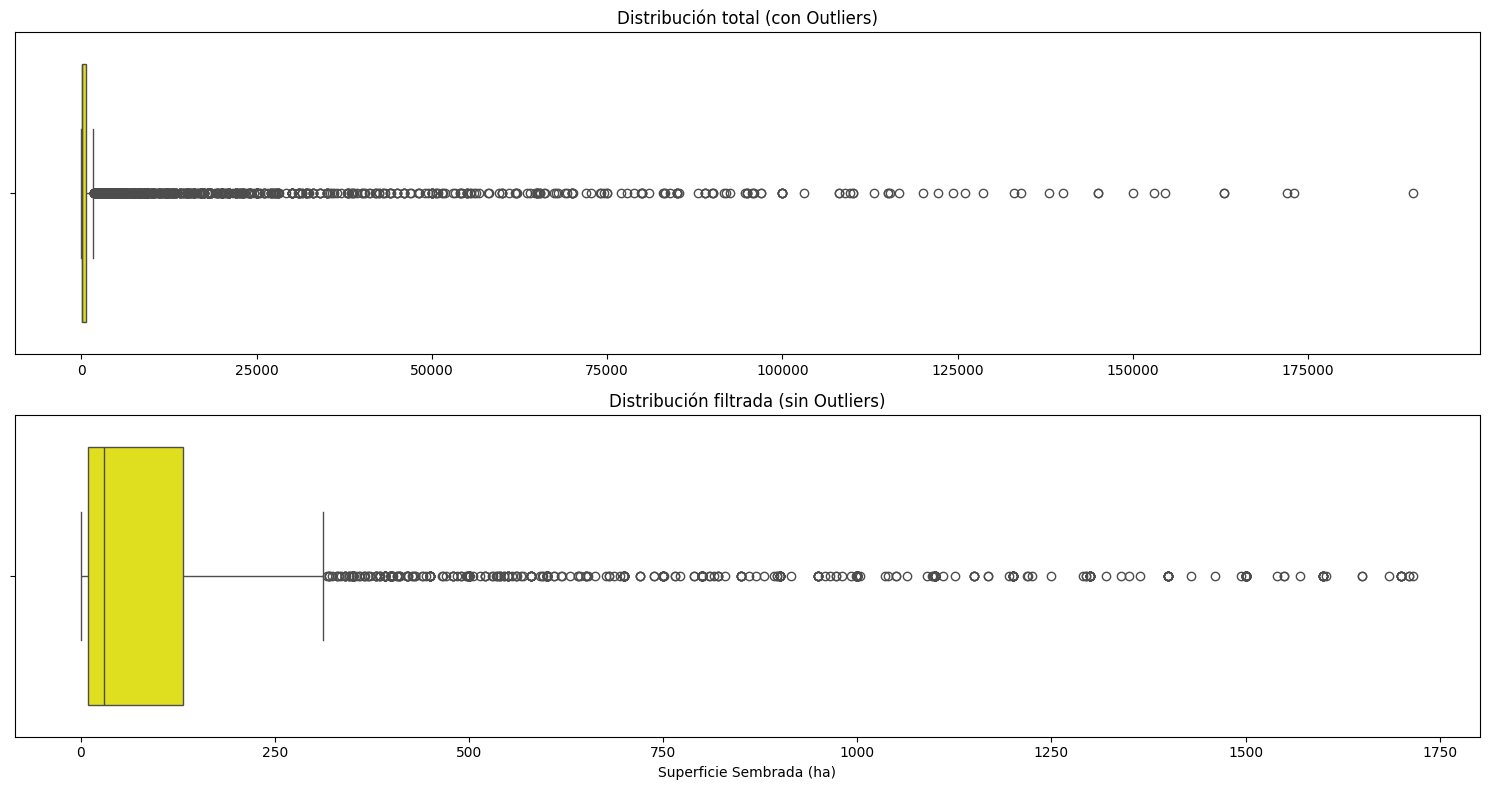

In [185]:
Q1, Q2, Q3 = df['superficie_sembrada_ha'].quantile([0.25, 0.50, 0.75])
IQR = Q3 - Q1

# Límites teóricos para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


# Generamos una figura con dos graficos en una columna, sin restringir el eje X porque hay muchos outliers.
fig, ax = plt.subplots(2, 1, figsize=(15, 8))

# Definimos los datos del primer grafico "ax[0]" el cual incluye los outliers.
sns.boxplot(
    data=df, 
    x='superficie_sembrada_ha',
    ax=ax[0], 
    color='yellow'
)


ax[0].set_title('Distribución total (con Outliers)')
ax[0].set_xlabel('')

# Definimos los datos del segundo grafico "ax[1]" el cual no incluye los outliers.
df_filtrado = df[df['superficie_sembrada_ha'].between(limite_inferior, limite_superior)]

sns.boxplot(
    data=df_filtrado, 
    x='superficie_sembrada_ha', 
    ax=ax[1], 
    color='yellow'
)

ax[1].set_title('Distribución filtrada (sin Outliers)')
ax[1].set_xlabel('Superficie Sembrada (ha)')

plt.tight_layout()
plt.show()

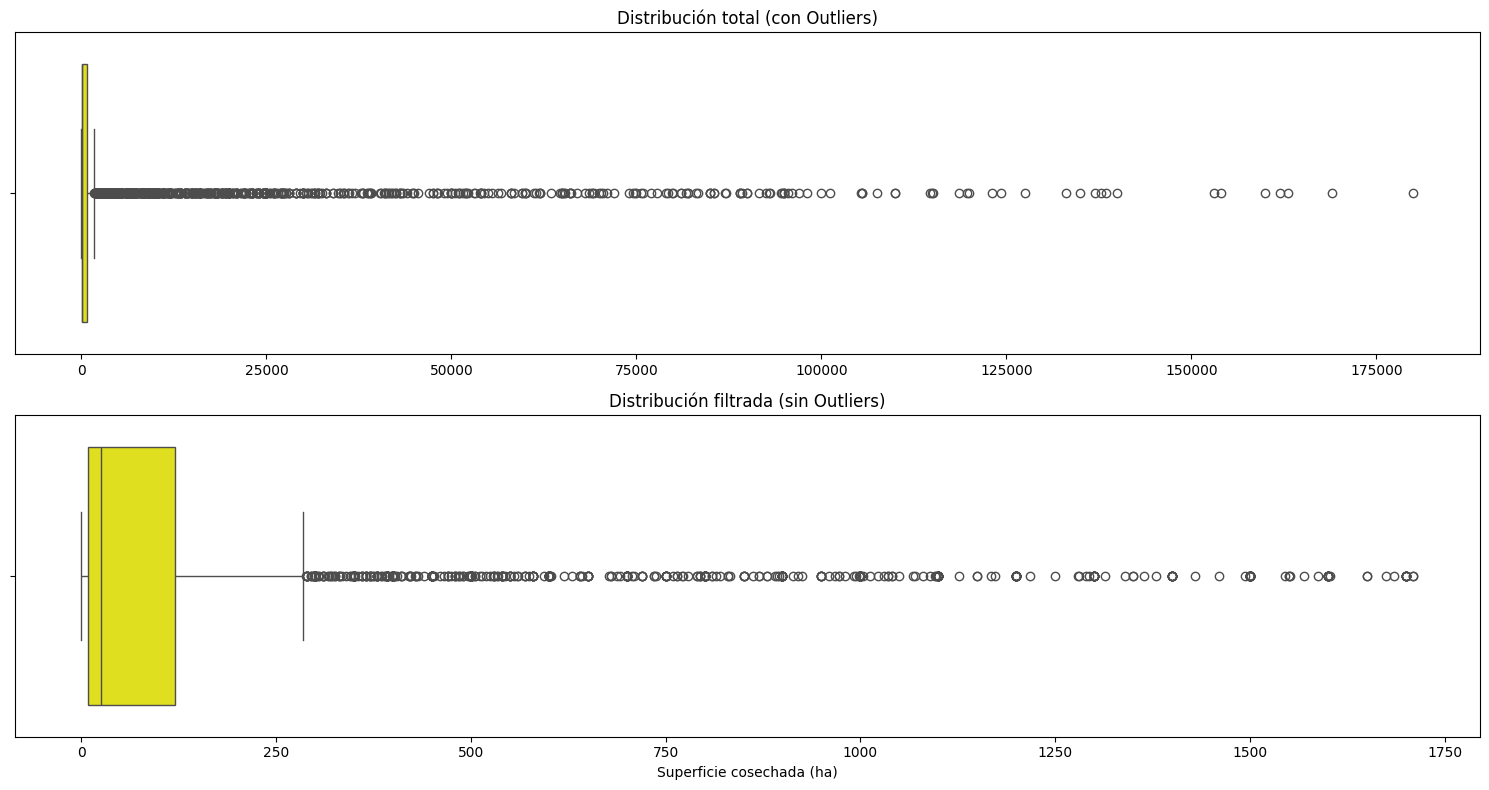

In [186]:
Q1, Q2, Q3 = df['superficie_cosechada_ha'].quantile([0.25, 0.50, 0.75])
IQR = Q3 - Q1

# Límites teóricos para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


# Generamos una figura con dos graficos en una columna, sin restringir el eje X porque hay muchos outliers.
fig, ax = plt.subplots(2, 1, figsize=(15, 8))

# Definimos los datos del primer grafico "ax[0]" el cual incluye los outliers.
sns.boxplot(
    data=df, 
    x='superficie_cosechada_ha',
    ax=ax[0], 
    color='yellow'
)


ax[0].set_title('Distribución total (con Outliers)')
ax[0].set_xlabel('')

# Definimos los datos del segundo grafico "ax[1]" el cual no incluye los outliers.
df_filtrado = df[df['superficie_cosechada_ha'].between(limite_inferior, limite_superior)]

sns.boxplot(
    data=df_filtrado, 
    x='superficie_cosechada_ha', 
    ax=ax[1], 
    color='yellow'
)

ax[1].set_title('Distribución filtrada (sin Outliers)')
ax[1].set_xlabel('Superficie cosechada (ha)')

plt.tight_layout()
plt.show()

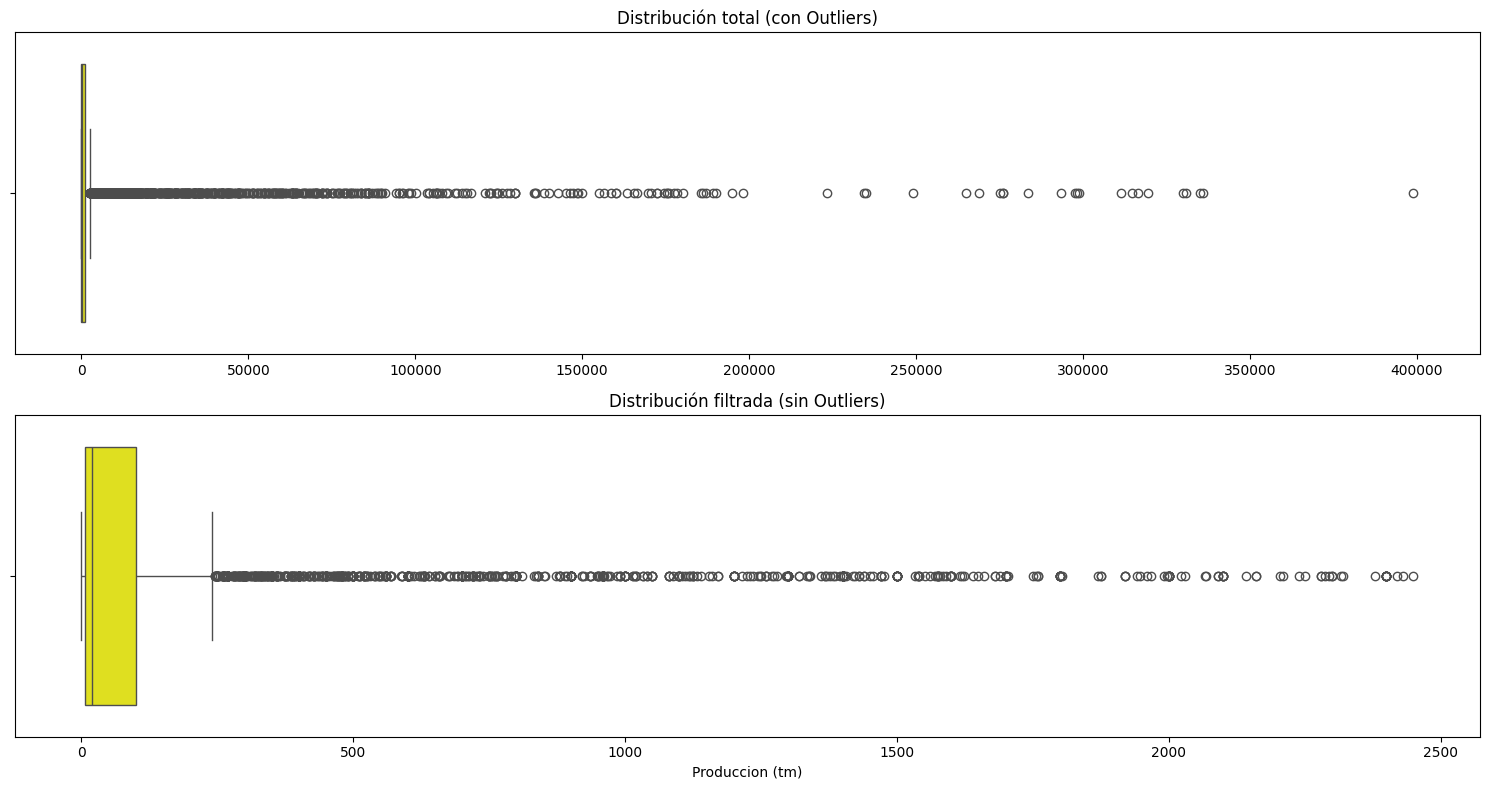

In [187]:
Q1, Q2, Q3 = df['produccion_tm'].quantile([0.25, 0.50, 0.75])
IQR = Q3 - Q1

# Límites teóricos para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


# Generamos una figura con dos graficos en una columna, sin restringir el eje X porque hay muchos outliers.
fig, ax = plt.subplots(2, 1, figsize=(15, 8))

# Definimos los datos del primer grafico "ax[0]" el cual incluye los outliers.
sns.boxplot(
    data=df, 
    x='produccion_tm',
    ax=ax[0], 
    color='yellow'
)


ax[0].set_title('Distribución total (con Outliers)')
ax[0].set_xlabel('')

# Definimos los datos del segundo grafico "ax[1]" el cual no incluye los outliers.
df_filtrado = df[df['produccion_tm'].between(limite_inferior, limite_superior)]

sns.boxplot(
    data=df_filtrado, 
    x='produccion_tm', 
    ax=ax[1], 
    color='yellow'
)

ax[1].set_title('Distribución filtrada (sin Outliers)')
ax[1].set_xlabel('Produccion (tm)')

plt.tight_layout()
plt.show()

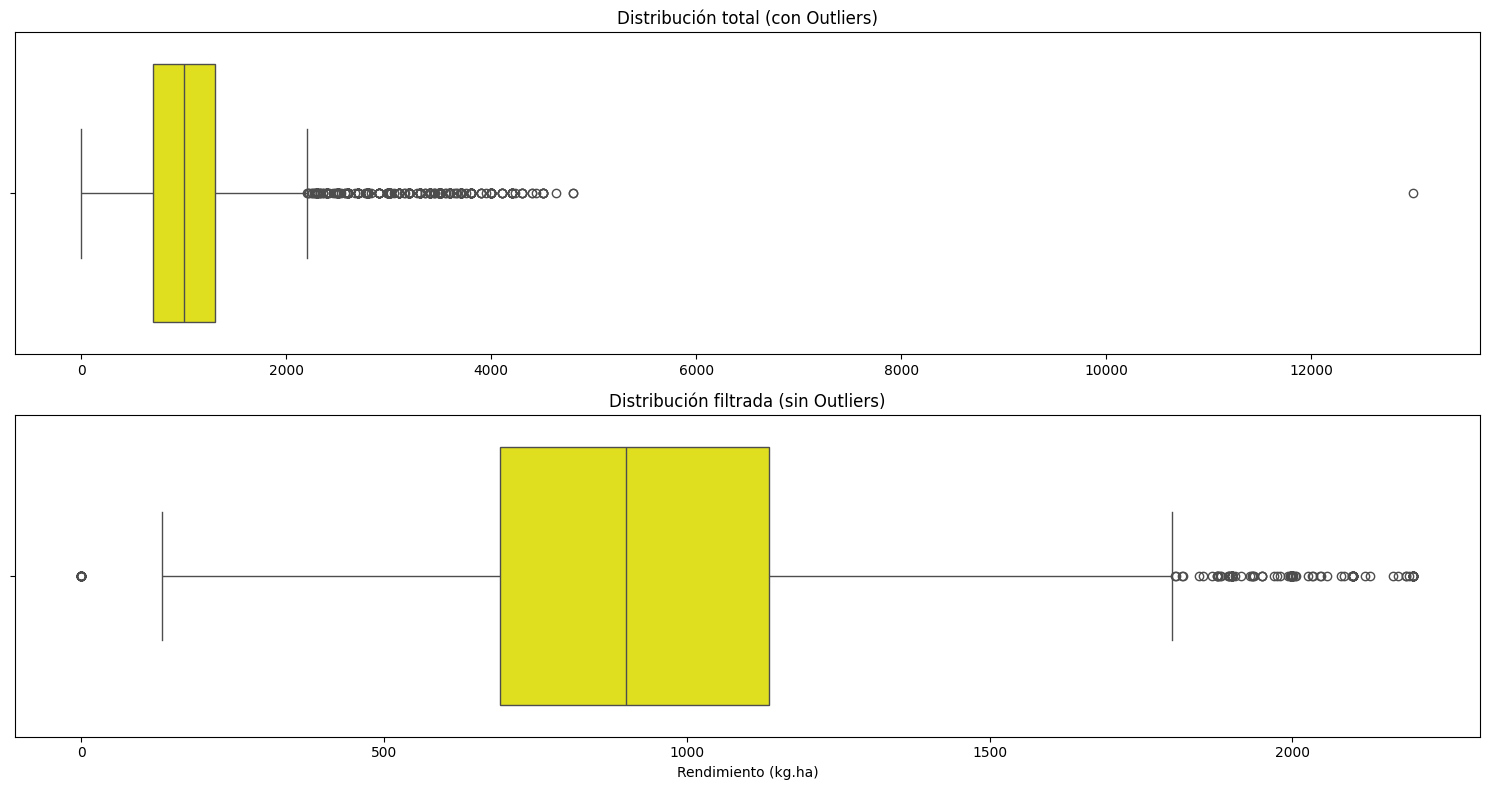

In [188]:
Q1, Q2, Q3 = df['rendimiento_kgxha'].quantile([0.25, 0.50, 0.75])
IQR = Q3 - Q1

# Límites teóricos para detectar outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


# Generamos una figura con dos graficos en una columna, sin restringir el eje X porque hay muchos outliers.
fig, ax = plt.subplots(2, 1, figsize=(15, 8))

# Definimos los datos del primer grafico "ax[0]" el cual incluye los outliers.
sns.boxplot(
    data=df, 
    x='rendimiento_kgxha',
    ax=ax[0], 
    color='yellow'
)


ax[0].set_title('Distribución total (con Outliers)')
ax[0].set_xlabel('')

# Definimos los datos del segundo grafico "ax[1]" el cual no incluye los outliers.
df_filtrado = df[df['rendimiento_kgxha'].between(limite_inferior, limite_superior)]

sns.boxplot(
    data=df_filtrado, 
    x='rendimiento_kgxha', 
    ax=ax[1], 
    color='yellow'
)

ax[1].set_title('Distribución filtrada (sin Outliers)')
ax[1].set_xlabel('Rendimiento (kg.ha)')

plt.tight_layout()
plt.show()

* VARIANZA Y DESVIACION ESTANDAR

In [195]:
# Calculamos la media, varianza y desviación estándar del largo de las aletas
media = df['superficie_sembrada_ha'].mean()
varianza = df['superficie_sembrada_ha'].var()
desviacion_estandar = df['superficie_sembrada_ha'].std()

print(f'La media es: {media:.2f}') 
print(f'La varianza es: {varianza:.2f}') 
print(f'La desviacion estandar es: {desviacion_estandar:.2f}') 

La media es: 4356.96
La varianza es: 242802411.58
La desviacion estandar es: 15582.12


### Medidas de relacion entre dos variables numericas: coeficientes de correlacion de Pearson, Spearman y Kendall

* Superficie sembrada vs superficie cosechada

In [203]:
C_pearson = df['superficie_sembrada_ha'].corr(df['superficie_cosechada_ha'], method='pearson')
C_spearman = df['superficie_sembrada_ha'].corr(df['superficie_cosechada_ha'], method='spearman')
C_kendall = df['superficie_sembrada_ha'].corr(df['superficie_cosechada_ha'], method='kendall')

print(f'La correlaacion de pearson es: {C_pearson:.2f}') 
print(f'La correlaacion de spearman es: {C_spearman:.2f}') 
print(f'La correlaacion de kendall es: {C_kendall:.2f}') 

La correlaacion de pearson es: 1.00
La correlaacion de spearman es: 0.99
La correlaacion de kendall es: 0.96


* Superficie sembrada vs produccion

In [204]:
C_pearson = df['superficie_sembrada_ha'].corr(df['produccion_tm'], method='pearson')
C_spearman = df['superficie_sembrada_ha'].corr(df['produccion_tm'], method='spearman')
C_kendall = df['superficie_sembrada_ha'].corr(df['produccion_tm'], method='kendall')

print(f'La correlaacion de pearson es: {C_pearson:.2f}') 
print(f'La correlaacion de spearman es: {C_spearman:.2f}') 
print(f'La correlaacion de kendall es: {C_kendall:.2f}') 

La correlaacion de pearson es: 0.88
La correlaacion de spearman es: 0.97
La correlaacion de kendall es: 0.89
